In [8]:
import yfinance as yf
import os

#Ensure the Resources folder exists
if not os.path.exists("Resources"):
    os.makedirs("Resources")
#Download the S&P 500 Dataset from Yahoo Finance
print("Downloading data...")
data =yf.download("^GSPC", start="2018-01-01", end="2025-01-01")

#save as a csv
# This flattens the file so the columns are simple: Date, Open, High, Low, Close
data.to_csv("Resources/sp500_stock_data.csv", index=True)

print("Success! 'sp500_stock_data.csv' is now in your Resources folder.")

[*********************100%***********************]  1 of 1 completed

Success! 'sp500_stock_data.csv' is now in your Resources folder.


In [11]:
import csv
import os

csvpath = os.path.join("Resources", "sp500_stock_data.csv")

max_pct_change = 0
max_change_date = "No Date Found"

with open(csvpath, 'r') as csvfile:
    csvreader = csv.DictReader(csvfile)
    
    # Debug: This helps us see if the column is 'Date', 'index', or something else
    columns = csvreader.fieldnames
    date_col = columns[0] # Usually the first column is the date
    
    for row in csvreader:
        try:
            opening_price = float(row["Open"])
            closing_price = float(row["Close"])
            
            pct_change = ((closing_price - opening_price) / opening_price) * 100
            
            if abs(pct_change) > max_pct_change:
                max_pct_change = abs(pct_change)
                # Use the detected date column name
                max_change_date = row[date_col]
                
        except (ValueError, KeyError, TypeError):
            continue

print(f"--- S&P 500 Analysis Results ---")
print(f"Column used for Date: {date_col}")
print(f"The most volatile day was: {max_change_date}")
print(f"The absolute percent change was: {max_pct_change:.2f}%")

--- S&P 500 Analysis Results ---
Column used for Date: Price
The most volatile day was: 2020-03-12
The absolute percent change was: 5.71%


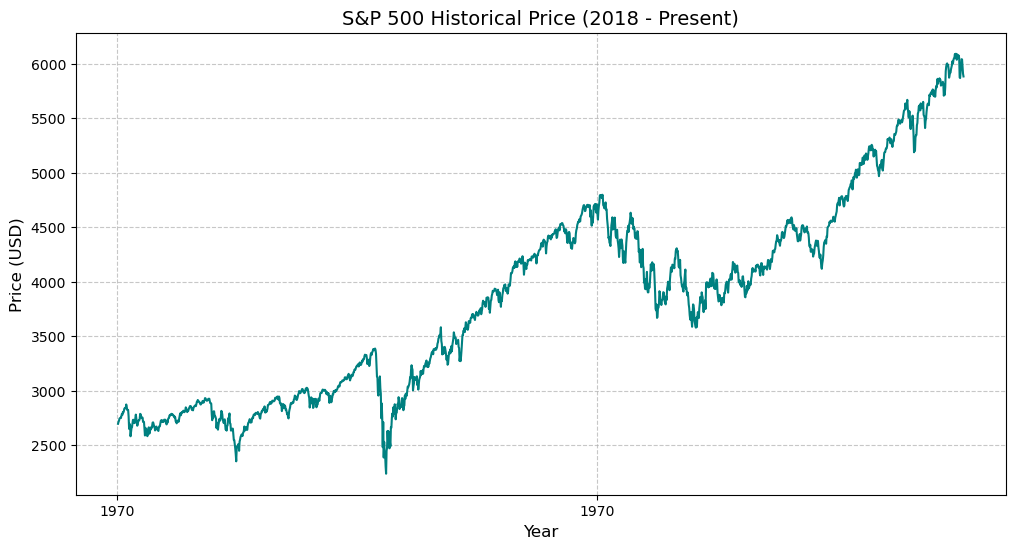

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv(csvpath)

if 'Date' not in df.columns:
    df = df.reset_index()
if 'Date' not in df.columns:
    df.rename(columns={df.columns[0]: 'Date'}, inplace=True)

# 3. CLEAN THE DATA 
# Force 'Close' to be numeric. 'errors=coerce' turns text like '^GSPC' into NaN (empty)
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop any rows that became empty (like header rows)
df = df.dropna(subset=['Date', 'Close'])

# 4. Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], color='teal', linewidth=1.5)

plt.title('S&P 500 Historical Price (2018 - Present)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()